We are going to try to create a model for each restaurant to if that gives better results.

In [1]:
# ============================================================
# STORE-SPECIFIC MODEL TRAINING AND EVALUATION
# One model for each restaurant
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_squared_log_error,
    r2_score
)

# ------------------------------------------------------------
# 1. Load final model-ready dataset
# ------------------------------------------------------------

DATA_DIR = Path("top_3_data")

df = pd.read_csv(DATA_DIR / "top3_model_ready_training_data.csv")

df["visit_date"] = pd.to_datetime(df["visit_date"])
df = df.sort_values(["air_store_id", "visit_date"]).reset_index(drop=True)

print("Dataset shape:", df.shape)
print("Number of restaurants:", df["air_store_id"].nunique())
print("Restaurants:")
print(df["air_store_id"].unique())

Dataset shape: (1345, 27)
Number of restaurants: 3
Restaurants:
['air_36bcf77d3382d36e' 'air_5c817ef28f236bdf' 'air_a083834e7ffe187e']


In [2]:
# ------------------------------------------------------------
# 2. Define target and features
# ------------------------------------------------------------

target = "visitors"

features = [
    # Calendar features
    "holiday_flg",
    "month",
    "day",
    "year",
    "week_of_year",
    "day_of_week_num",
    "is_weekend",

    # Location features
    "latitude",
    "longitude",

    # Reservation features
    "reserved_visitors_sum",
    "reservation_count",
    "reserved_visitors_mean",
    "avg_reserve_lead_days",
    "has_reservation_data",

    # Historical visitor features
    "visitors_lag_1",
    "visitors_lag_7",
    "visitors_lag_14",
    "visitors_lag_28",
    "visitors_rolling_7_mean",
    "visitors_rolling_14_mean",
    "visitors_rolling_28_mean",

    # Restaurant information
    "air_genre_name",
    "air_area_name"
]

# Keep only columns that exist in your dataframe
features = [col for col in features if col in df.columns]

print("Features used:")
print(features)
print("Number of features:", len(features))

Features used:
['holiday_flg', 'month', 'day', 'year', 'week_of_year', 'day_of_week_num', 'is_weekend', 'latitude', 'longitude', 'reserved_visitors_sum', 'reservation_count', 'reserved_visitors_mean', 'avg_reserve_lead_days', 'has_reservation_data', 'visitors_lag_1', 'visitors_lag_7', 'visitors_lag_14', 'visitors_lag_28', 'visitors_rolling_7_mean', 'visitors_rolling_14_mean', 'visitors_rolling_28_mean', 'air_genre_name', 'air_area_name']
Number of features: 23


In [3]:
# ------------------------------------------------------------
# 3. Train separate model for each restaurant
# ------------------------------------------------------------

TEST_DAYS = 39

restaurant_models = {}
all_results = []
restaurant_metrics = []

for restaurant_id in df["air_store_id"].unique():
    
    print("\n========================================")
    print("Training model for:", restaurant_id)
    print("========================================")
    
    # Get data for one restaurant
    restaurant_df = df[df["air_store_id"] == restaurant_id].copy()
    restaurant_df = restaurant_df.sort_values("visit_date")
    
    # Split last 39 days as test data
    train_df = restaurant_df.iloc[:-TEST_DAYS]
    test_df = restaurant_df.iloc[-TEST_DAYS:]
    
    print("Training rows:", len(train_df))
    print("Testing rows:", len(test_df))
    print("Test date range:", test_df["visit_date"].min(), "to", test_df["visit_date"].max())
    
    # Split features and target
    X_train = train_df[features]
    y_train = train_df[target]
    
    X_test = test_df[features]
    y_test = test_df[target]
    
    # One-hot encode categorical columns
    X_train_encoded = pd.get_dummies(X_train)
    X_test_encoded = pd.get_dummies(X_test)
    
    # Align columns
    X_train_encoded, X_test_encoded = X_train_encoded.align(
        X_test_encoded,
        join="left",
        axis=1,
        fill_value=0
    )
    
    # Create model
    model = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        max_depth=12,
        min_samples_leaf=3,
        max_features="sqrt"
    )
    
    # Train model
    model.fit(X_train_encoded, y_train)
    
    # Predict
    predictions = model.predict(X_test_encoded)
    predictions = np.maximum(predictions, 0)
    
    # Save model
    restaurant_models[restaurant_id] = model
    
    # Create result table for this restaurant
    temp_results = test_df[["air_store_id", "visit_date", "visitors"]].copy()
    temp_results["predicted_visitors"] = predictions
    temp_results["predicted_visitors_rounded"] = np.round(predictions).astype(int)
    temp_results["absolute_error"] = abs(temp_results["visitors"] - temp_results["predicted_visitors"])
    
    all_results.append(temp_results)
    
    # Metrics for this restaurant
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    rmsle = np.sqrt(mean_squared_log_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    
    mean_actual = y_test.mean()
    practical_accuracy = (1 - (mae / mean_actual)) * 100
    
    restaurant_metrics.append({
        "air_store_id": restaurant_id,
        "training_rows": len(train_df),
        "testing_rows": len(test_df),
        "mean_actual_visitors": mean_actual,
        "mae": mae,
        "rmse": rmse,
        "rmsle": rmsle,
        "r2_score": r2,
        "practical_accuracy_percent": practical_accuracy
    })
    
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"RMSLE: {rmsle:.4f}")
    print(f"R² Score: {r2:.4f}")
    print(f"Practical Accuracy: {practical_accuracy:.2f}%")


Training model for: air_36bcf77d3382d36e
Training rows: 409
Testing rows: 39
Test date range: 2017-03-15 00:00:00 to 2017-04-22 00:00:00
MAE: 7.97
RMSE: 10.17
RMSLE: 0.3152
R² Score: 0.6403
Practical Accuracy: 73.69%

Training model for: air_5c817ef28f236bdf
Training rows: 410
Testing rows: 39
Test date range: 2017-03-15 00:00:00 to 2017-04-22 00:00:00
MAE: 12.04
RMSE: 14.77
RMSLE: 0.4450
R² Score: 0.6071
Practical Accuracy: 73.19%

Training model for: air_a083834e7ffe187e
Training rows: 409
Testing rows: 39
Test date range: 2017-03-14 00:00:00 to 2017-04-22 00:00:00
MAE: 4.97
RMSE: 6.58
RMSLE: 0.4544
R² Score: 0.7588
Practical Accuracy: 79.36%


In [4]:
# ------------------------------------------------------------
# 4. Combine results from all restaurant-specific models
# ------------------------------------------------------------

store_specific_results = pd.concat(all_results).reset_index(drop=True)

restaurant_metrics_df = pd.DataFrame(restaurant_metrics)

store_specific_results.head()

,air_store_id,visit_date,visitors,predicted_visitors,predicted_visitors_rounded,absolute_error
0,air_36bcf77d3382d36e,2017-03-15,21,20.666810,21,0.333190
1,air_36bcf77d3382d36e,2017-03-16,24,22.680579,23,1.319421
2,air_36bcf77d3382d36e,2017-03-17,27,25.162625,25,1.837375
3,air_36bcf77d3382d36e,2017-03-18,30,57.776463,58,27.776463
4,air_36bcf77d3382d36e,2017-03-19,41,54.030705,54,13.030705


In [5]:
restaurant_metrics_df

,air_store_id,training_rows,testing_rows,mean_actual_visitors,mae,rmse,rmsle,r2_score,practical_accuracy_percent
0,air_36bcf77d3382d36e,409,39,30.307692,7.972964,10.165031,0.315163,0.640272,73.693266
1,air_5c817ef28f236bdf,410,39,44.923077,12.044951,14.769354,0.445022,0.607071,73.187610
2,air_a083834e7ffe187e,409,39,24.102564,4.974363,6.580358,0.454382,0.758806,79.361687


In [6]:
store_specific_results.to_csv(
    DATA_DIR / "store_specific_daily_prediction_results.csv",
    index=False
)

restaurant_metrics_df.to_csv(
    DATA_DIR / "store_specific_restaurant_metrics.csv",
    index=False
)

print("Store-specific daily results and metrics saved.")

Store-specific daily results and metrics saved.


In [7]:
# ------------------------------------------------------------
# 5. Overall evaluation
# ------------------------------------------------------------

y_true = store_specific_results["visitors"]
y_pred = store_specific_results["predicted_visitors"]

overall_mae = mean_absolute_error(y_true, y_pred)
overall_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
overall_rmsle = np.sqrt(mean_squared_log_error(y_true, y_pred))
overall_r2 = r2_score(y_true, y_pred)

overall_mean_actual = y_true.mean()
overall_practical_accuracy = (1 - (overall_mae / overall_mean_actual)) * 100

print("STORE-SPECIFIC MODEL OVERALL EVALUATION")
print("---------------------------------------")
print(f"MAE  - Average error in visitors: {overall_mae:.2f}")
print(f"RMSE - Root mean squared error: {overall_rmse:.2f}")
print(f"RMSLE - Log error score: {overall_rmsle:.4f}")
print(f"R² Score: {overall_r2:.4f}")
print(f"Mean actual visitors: {overall_mean_actual:.2f}")
print(f"Practical accuracy estimate: {overall_practical_accuracy:.2f}%")

STORE-SPECIFIC MODEL OVERALL EVALUATION
---------------------------------------
MAE  - Average error in visitors: 8.33
RMSE - Root mean squared error: 11.03
RMSLE - Log error score: 0.4098
R² Score: 0.7083
Mean actual visitors: 33.11
Practical accuracy estimate: 74.84%


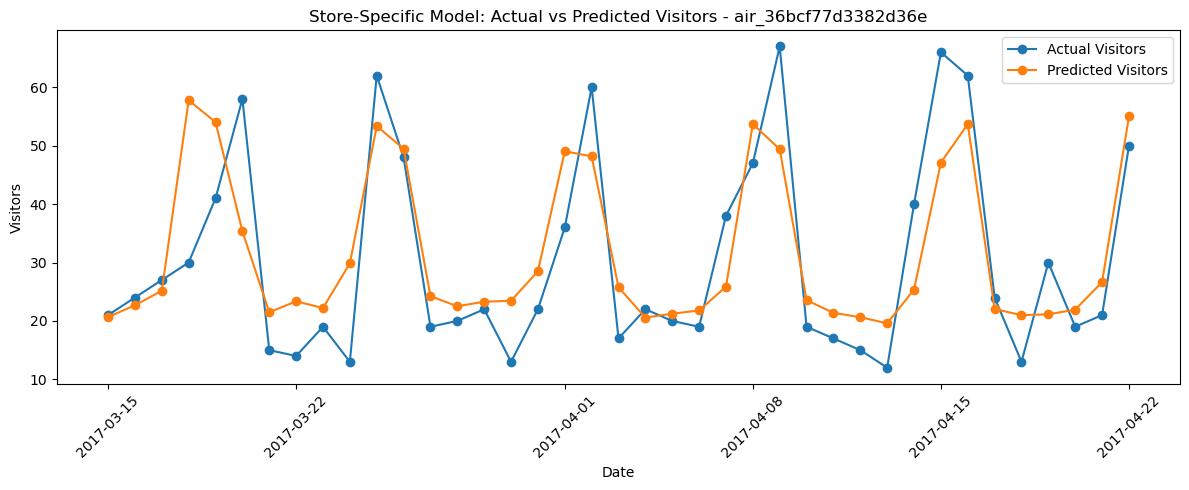

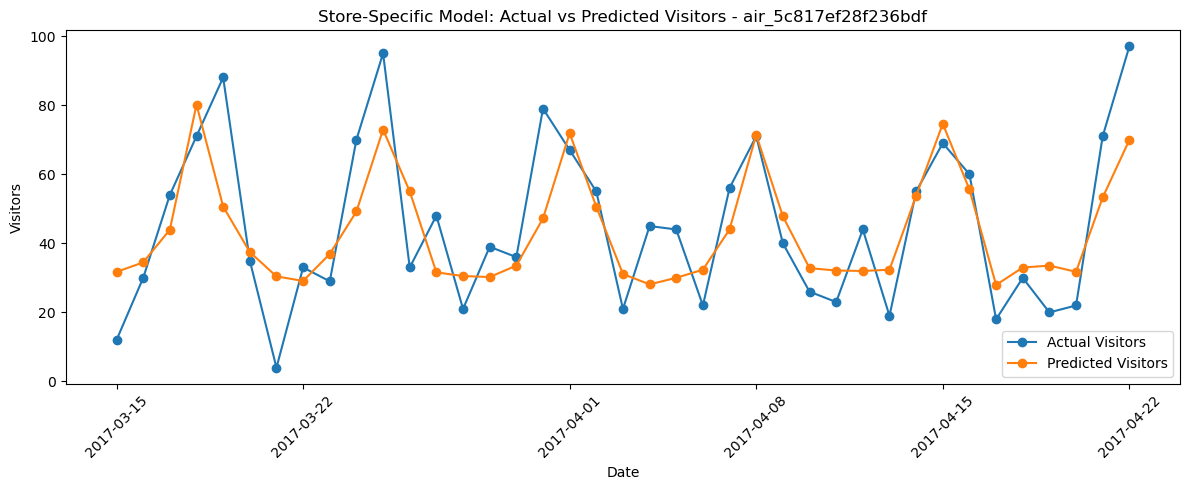

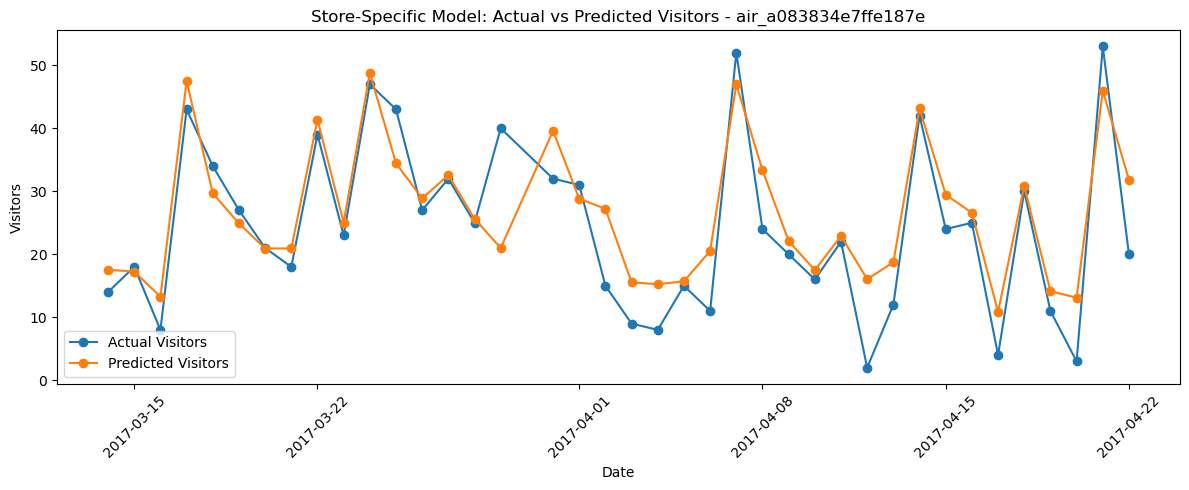

In [8]:
# ------------------------------------------------------------
# 6. Plot actual vs predicted visitors
# ------------------------------------------------------------

for restaurant_id in store_specific_results["air_store_id"].unique():
    
    temp = store_specific_results[
        store_specific_results["air_store_id"] == restaurant_id
    ].copy()
    
    plt.figure(figsize=(12, 5))
    plt.plot(
        temp["visit_date"],
        temp["visitors"],
        marker="o",
        label="Actual Visitors"
    )
    plt.plot(
        temp["visit_date"],
        temp["predicted_visitors"],
        marker="o",
        label="Predicted Visitors"
    )
    
    plt.title(f"Store-Specific Model: Actual vs Predicted Visitors - {restaurant_id}")
    plt.xlabel("Date")
    plt.ylabel("Visitors")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [9]:
# ------------------------------------------------------------
# 7. Weekly aggregation for store-specific models
# ------------------------------------------------------------

daily_predictions = store_specific_results.copy()

daily_predictions["visit_date"] = pd.to_datetime(daily_predictions["visit_date"])

daily_predictions["week_start"] = (
    daily_predictions["visit_date"]
    - pd.to_timedelta(daily_predictions["visit_date"].dt.weekday, unit="D")
)

daily_predictions["week_end"] = daily_predictions["week_start"] + pd.Timedelta(days=6)

store_specific_weekly_predictions = (
    daily_predictions
    .groupby(["air_store_id", "week_start", "week_end"])
    .agg(
        days_in_week=("visit_date", "count"),
        actual_weekly_visitors=("visitors", "sum"),
        predicted_weekly_visitors=("predicted_visitors", "sum"),
        predicted_weekly_visitors_rounded=("predicted_visitors_rounded", "sum"),
        average_daily_error=("absolute_error", "mean")
    )
    .reset_index()
)

store_specific_weekly_predictions["weekly_absolute_error"] = abs(
    store_specific_weekly_predictions["actual_weekly_visitors"]
    - store_specific_weekly_predictions["predicted_weekly_visitors"]
)

store_specific_weekly_predictions["weekly_practical_accuracy_percent"] = (
    1 - (
        store_specific_weekly_predictions["weekly_absolute_error"]
        / store_specific_weekly_predictions["actual_weekly_visitors"]
    )
) * 100

store_specific_weekly_predictions

,air_store_id,week_start,week_end,days_in_week,actual_weekly_visitors,predicted_weekly_visitors,predicted_weekly_visitors_rounded,average_daily_error,weekly_absolute_error,weekly_practical_accuracy_percent
0,air_36bcf77d3382d36e,2017-03-13,2017-03-19,5,143,180.317182,181,8.859431,37.317182,73.904069
1,air_36bcf77d3382d36e,2017-03-20,2017-03-26,7,229,235.091733,233,9.816769,6.091733,97.339855
2,air_36bcf77d3382d36e,2017-03-27,2017-04-02,7,192,219.221349,219,7.269288,27.221349,85.822214
3,air_36bcf77d3382d36e,2017-04-03,2017-04-09,7,230,218.331244,219,7.238343,11.668756,94.926628
4,air_36bcf77d3382d36e,2017-04-10,2017-04-16,7,231,211.339641,212,9.140853,19.660359,91.489022
5,air_36bcf77d3382d36e,2017-04-17,2017-04-23,6,157,167.764850,168,5.398611,10.764850,93.143407
6,air_5c817ef28f236bdf,2017-03-13,2017-03-19,5,255,240.943759,241,16.154582,14.056241,94.487749
7,air_5c817ef28f236bdf,2017-03-20,2017-03-26,7,299,311.051429,310,15.083434,12.051429,95.969422
8,air_5c817ef28f236bdf,2017-03-27,2017-04-02,7,345,295.551009,297,11.177359,49.448991,85.666959
9,air_5c817ef28f236bdf,2017-04-03,2017-04-09,7,299,284.846086,284,10.223055,14.153914,95.266249


In [10]:
store_specific_weekly_predictions.to_csv(
    DATA_DIR / "store_specific_weekly_prediction_results.csv",
    index=False
)

print("Store-specific weekly predictions saved.")

Store-specific weekly predictions saved.


In [11]:
# ------------------------------------------------------------
# 8. Full-week evaluation
# ------------------------------------------------------------

full_week_store_specific = store_specific_weekly_predictions[
    store_specific_weekly_predictions["days_in_week"] == 7
].copy()

print("Total weekly rows:", len(store_specific_weekly_predictions))
print("Full 7-day weekly rows:", len(full_week_store_specific))

if len(full_week_store_specific) > 0:
    
    weekly_mae = mean_absolute_error(
        full_week_store_specific["actual_weekly_visitors"],
        full_week_store_specific["predicted_weekly_visitors"]
    )
    
    weekly_rmse = np.sqrt(mean_squared_error(
        full_week_store_specific["actual_weekly_visitors"],
        full_week_store_specific["predicted_weekly_visitors"]
    ))
    
    weekly_r2 = r2_score(
        full_week_store_specific["actual_weekly_visitors"],
        full_week_store_specific["predicted_weekly_visitors"]
    )
    
    weekly_mean_actual = full_week_store_specific["actual_weekly_visitors"].mean()
    
    weekly_practical_accuracy = (1 - (weekly_mae / weekly_mean_actual)) * 100
    
    print("STORE-SPECIFIC FULL-WEEK EVALUATION")
    print("-----------------------------------")
    print(f"Full-week MAE: {weekly_mae:.2f} visitors")
    print(f"Full-week RMSE: {weekly_rmse:.2f} visitors")
    print(f"Full-week R² Score: {weekly_r2:.4f}")
    print(f"Mean actual full-week visitors: {weekly_mean_actual:.2f}")
    print(f"Full-week practical accuracy estimate: {weekly_practical_accuracy:.2f}%")
else:
    print("No full 7-day weeks found.")

Total weekly rows: 18
Full 7-day weekly rows: 11
STORE-SPECIFIC FULL-WEEK EVALUATION
-----------------------------------
Full-week MAE: 20.15 visitors
Full-week RMSE: 23.94 visitors
Full-week R² Score: 0.8561
Mean actual full-week visitors: 238.27
Full-week practical accuracy estimate: 91.55%
